# Importing libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Functions

In [2]:
def normalize(data):
    normalized_data=(data-data.mean(axis=0))/data.std(axis=0)
    return normalized_data

def denormalize(values,data):
    denormalized_data=values*data.std(axis=0)+data.mean(axis=0)
    return denormalized_data


In [3]:
class LinearRegression:
    
    def __init__(self,X,Y):
        
        self.X=X
        self.Y=Y
        self.weights=np.ones(X.shape[1])
        self.bias=np.ones(1)
        self.cost=[]

    def cost_function(self):
        
        error=(self.X.dot(self.weights)+self.bias-self.Y)**2
        return np.sum(error)/(2*len(self.Y))

    def gradients(self,alpha):
        
        loss=(self.X.dot(self.weights)+self.bias)-self.Y
        weights_grad=self.X.T.dot(loss)/len(self.Y)
        bias_grad=np.sum(loss)/len(self.Y)

        self.weights=self.weights-alpha*weights_grad
        self.bias=self.bias-alpha*bias_grad

        return self.weights,self.bias
    
    def fit(self,num_iterations=3000,alpha=0.005):

        for i in range(num_iterations):
            self.cost.append(self.cost_function())
            weights,bias=self.gradients(alpha)
          
        prediction=self.X.dot(self.weights) + self.bias
        estimated_variance = np.sum((prediction - self.Y)**2) / (len(self.Y) - self.X.shape[1] - 1)
        XTX_inverse = np.linalg.inv(self.X.T.dot(self.X))
        cov_matrix = estimated_variance * XTX_inverse
         
        prediction_variance=np.sum((self.Y- prediction)**2)
        variance_of_y=np.sum((self.Y- np.mean(self.Y))**2)
        
        self.std_errors = np.sqrt(np.diag(cov_matrix))
        self.t_stat=self.weights/self.std_errors
        
        self.r2=1-prediction_variance/variance_of_y
        self.r2_adjusted=1-((1-self.r2)*(len(self.Y)-1))/(len(self.Y)-self.X.shape[1]-1)

        return weights,bias
        
    def predict(self,X):
        return (X.dot(self.weights)+self.bias)
    
    def error(self):
        predictions=self.predict(self.X)
        data_predicted=np.column_stack((predictions,self.Y))
        
        return data_predicted
    


# Data Manipulation

In [4]:
file=pd.ExcelFile('Peers Perf 1.xlsx')
names=pd.read_excel('Returns Fund Name.xlsx',index_col=0)

In [5]:
sheet_names=file.sheet_names
perf_sheet=file.sheet_names
perf_sheet.remove('Fund List')

dict_data=file.parse(sheet_name=perf_sheet)

In [6]:
reworked_data={}
for key in dict_data:

    reworked_data[key]=dict_data[key].set_index('ISIN').T.dropna(axis=1, how='all')

## Since February 2024

In [7]:
#variable=sheet_names[0]
last_days=0


prices=pd.DataFrame()

for key in reworked_data:
    prices=pd.concat([prices,reworked_data[key]],axis=1)

returns=prices.copy().iloc[-last_days:]
returns=(1+returns.sort_index().fillna(method='bfill').pct_change()).cumprod()-1
returns.iloc[-1].to_excel('Returns.xlsx')

exposure=file.parse(sheet_name=sheet_names[-1])
exposure=exposure.set_index('ISIN')

categories=exposure['Fund'].unique()

maps={}
maps['Balanced']=1
maps['SGF']=2
maps['Conservative']=0

exposure['Equity']=exposure['European Equity']+exposure['US equity']
exposure['Returns']=returns.iloc[-1]
exposure['Fund Name']=names['Fund Name']
exposure['Categories']=exposure['Fund'].map(maps)

# Graphs

## Global Overview

In [8]:
exposure.sort_values(by='Returns',ascending=False).iloc[:10]

,Duration,US equity,European Equity,HY exposure,Fund,Equity,Returns,Fund Name,Categories
ISIN,,,,,,,,,
LU1839896005,NaN,0.747084,0.223007,NaN,SGF,0.970091,0.199572,boerse.de-Weltfonds TM,2
LU0904227583,NaN,0.601897,0.274815,NaN,SGF,0.876712,0.196768,Leadersel Dynamic Inc,2
LU0327386487,0.197232,0.685213,0.170659,NaN,SGF,0.855872,0.194722,AL GlobalAktiv+ LC,2
AT0000A29T31,0.134671,0.656513,0.226933,NaN,SGF,0.883446,0.192097,UCIP T,2
AT0000A0H858,1.219984,0.138032,0.182436,NaN,Balanced,0.320468,0.189339,Macro + Strategy R T,1
DE0005314249,3.343778,0.401413,0.250207,0.057671,Balanced,0.651620,0.188144,BBBank Wachstum Union,1
DE000A0Q8A07,NaN,0.658212,0.091752,NaN,SGF,0.749964,0.182078,CONCEPT Aurelia Global,2
DK0061112034,NaN,0.721145,0.178568,NaN,SGF,0.899713,0.181811,Wealth Invest Othania Allokeri VERDEN KL,2
LU0318314076,0.054409,0.653481,0.133855,NaN,Balanced,0.787336,0.178160,Finanzmatrix,1


### Balanced Top 10 Peers

In [9]:
exposure[exposure['Fund']==categories[0]].sort_values(by='Returns',ascending=False).iloc[:10]

,Duration,US equity,European Equity,HY exposure,Fund,Equity,Returns,Fund Name,Categories
ISIN,,,,,,,,,
AT0000A0H858,1.219984,0.138032,0.182436,NaN,Balanced,0.320468,0.189339,Macro + Strategy R T,1
DE0005314249,3.343778,0.401413,0.250207,0.057671,Balanced,0.651620,0.188144,BBBank Wachstum Union,1
LU0318314076,0.054409,0.653481,0.133855,NaN,Balanced,0.787336,0.178160,Finanzmatrix,1
DE000A2DTNG8,NaN,0.447476,0.314665,NaN,Balanced,0.762141,0.159348,OLB Invest Dynamik,1
ES0108232002,0.750000,0.566557,0.269111,NaN,Balanced,0.835668,0.157359,Allianz Cartera Dinamica FI,1
DE000A0Q2H06,5.517466,0.278664,0.279599,0.000000,Balanced,0.558263,0.156662,VR Westmünsterland Aktiv Nachhaltig,1
DE000A2PBFM4,4.713210,0.370735,0.347612,0.060037,Balanced,0.718347,0.154509,HSBC Horizont 16+ ID,1
DK0010106384,2.716720,0.490771,0.131464,NaN,Balanced,0.622236,0.142721,Jyske Invest Obligationer og Aktier KL,1
DK0060749448,NaN,0.410096,0.120052,NaN,Balanced,0.530148,0.132592,Sydinvest Vækstorienteret Udb A,1


### Conservative Top 10 Peers

In [10]:
exposure[exposure['Fund']==categories[1]].sort_values(by='Returns',ascending=False).iloc[:10]

,Duration,US equity,European Equity,HY exposure,Fund,Equity,Returns,Fund Name,Categories
ISIN,,,,,,,,,
ES0156572002,8.228182,0.063383,0.124907,NaN,Conservative,0.188290,0.089870,Myinvestor Cartera Permanente FI,0
DK0060749794,NaN,0.246409,0.069999,NaN,Conservative,0.316408,0.089101,Sydinvest Balanceret Akk A,0
DK0060749364,NaN,0.245029,0.071538,NaN,Conservative,0.316567,0.088960,Sydinvest Balanceret Udb A,0
LU2015234862,4.683750,0.130790,0.123333,0.127421,Conservative,0.254123,0.086598,EIS Mercurio 4,0
DE000A1H72E4,4.751673,0.260740,0.179540,NaN,Conservative,0.440280,0.086303,Zukunftsportfolio Nachhaltigkeit,0
FI0008812474,4.083542,0.172547,0.085663,NaN,Conservative,0.258210,0.085723,LähiTapiola Maailma 20,0
SE0017832017,3.100779,0.166122,0.099371,NaN,Conservative,0.265493,0.084783,Nordnet One Forsigtig DKK,0
DK0060762623,NaN,0.216988,0.078352,0.207208,Conservative,0.295340,0.084373,BankInvest Optima 30 KL,0
DK0060745966,NaN,0.216909,0.077872,0.206312,Conservative,0.294781,0.084087,BankInvest Optima 30 Akk KL,0


### Dynamic Top 10 Peers

In [11]:
exposure[exposure['Fund']==categories[2]].sort_values(by='Returns',ascending=False).iloc[:10]

,Duration,US equity,European Equity,HY exposure,Fund,Equity,Returns,Fund Name,Categories
ISIN,,,,,,,,,
LU1839896005,NaN,0.747084,0.223007,NaN,SGF,0.970091,0.199572,boerse.de-Weltfonds TM,2
LU0904227583,NaN,0.601897,0.274815,NaN,SGF,0.876712,0.196768,Leadersel Dynamic Inc,2
LU0327386487,0.197232,0.685213,0.170659,NaN,SGF,0.855872,0.194722,AL GlobalAktiv+ LC,2
AT0000A29T31,0.134671,0.656513,0.226933,NaN,SGF,0.883446,0.192097,UCIP T,2
DE000A0Q8A07,NaN,0.658212,0.091752,NaN,SGF,0.749964,0.182078,CONCEPT Aurelia Global,2
DK0061112034,NaN,0.721145,0.178568,NaN,SGF,0.899713,0.181811,Wealth Invest Othania Allokeri VERDEN KL,2
ES0174741035,NaN,0.457562,0.455832,NaN,SGF,0.913394,0.176123,Renta 4 Multigestión 2 Atria Inver Gl FI,2
LU2168558927,5.659033,0.726889,0.133640,NaN,SGF,0.860529,0.172195,AZ Fd1 AZ Allc Intl 50%-100% A-AZ Cap,2
LU0232090471,3.243524,0.333878,0.156354,0.435431,SGF,0.490232,0.168894,IAMF - TOP SELECT PORTFOLIO,2


### Regression

In [12]:
inputs=exposure.copy()
#inputs=inputs.interpolate()
inputs=inputs.dropna()

X=normalize(inputs[['Equity','Duration']])
Y=normalize(inputs['Returns'])

Reg=LinearRegression(X,Y)

weights,bias=Reg.fit()

In [13]:
x1_grid, x2_grid = np.meshgrid(np.linspace(-4,4, 1000),np.linspace(-4,6, 1000))
z=weights[0]*x1_grid+weights[1]*x2_grid+bias

equity=denormalize(x1_grid,inputs['Equity'])
duration=denormalize(x2_grid,inputs['Duration'])
score=denormalize(z,inputs['Returns'])

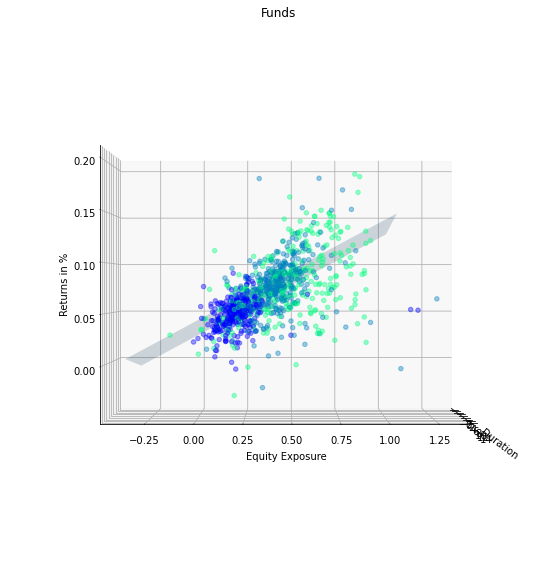

In [14]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(duration,equity,score,alpha=0.2
               )

ax.scatter(exposure['Duration'],exposure['Equity'],exposure['Returns'],
           c=exposure['Categories'],alpha=0.4
           , cmap='winter',zorder=0)


plt.title(label='Funds',
      fontweight=10,
      pad='2.0')

ax.set_xlabel("Duration",labelpad=10)
ax.set_ylabel("Equity Exposure",labelpad=10)
ax.set_zlabel("Returns in %")

elevation_angle = 0
azimuth_angle = 0
ax.view_init(elev=elevation_angle, azim=azimuth_angle)
plt.show()

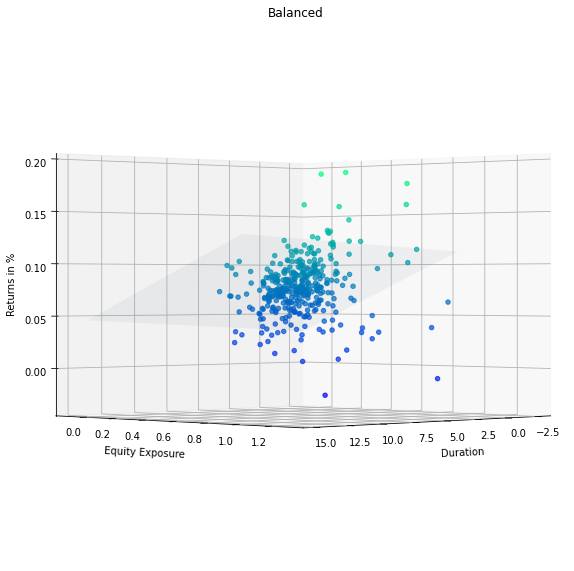

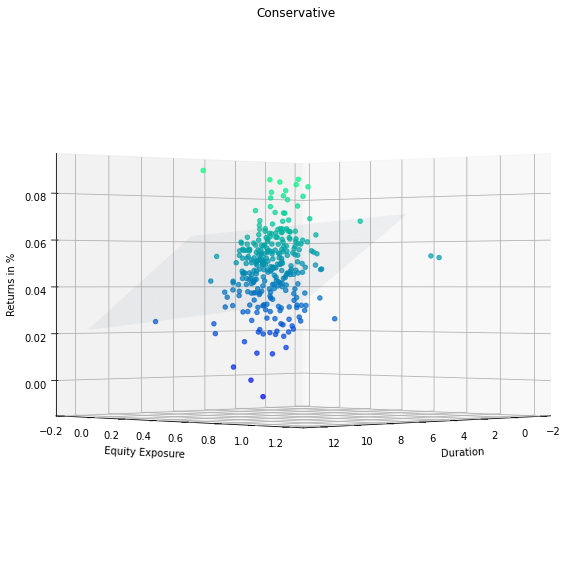

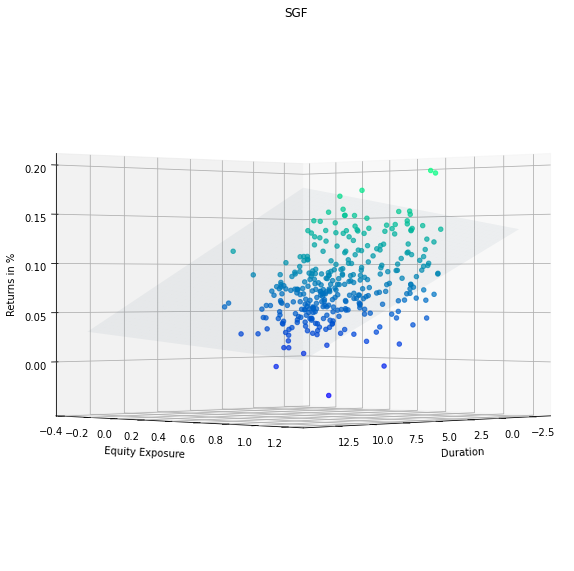

In [15]:
for variable in categories:
    
    
    inputs=exposure[exposure['Fund']==variable]
    inputs=inputs.dropna()


    X=normalize(inputs[['Equity','Duration']])
    Y=normalize(inputs['Returns'])
    Reg=LinearRegression(X,Y)
    weights,bias=Reg.fit()
    
    x1_grid, x2_grid = np.meshgrid(np.linspace(-4,4, 1000),np.linspace(-4,6, 1000))
    z=weights[0]*x1_grid+weights[1]*x2_grid+bias
    
    equity=denormalize(x1_grid,inputs['Equity'])
    duration=denormalize(x2_grid,inputs['Duration'])
    score=denormalize(z,inputs['Returns'])

    
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
     
    ax.plot_surface(duration,equity,score,alpha=0.05
               )
    
    
    ax.scatter(exposure[exposure['Fund']==variable]['Duration'],exposure[exposure['Fund']==variable]['Equity'],exposure[exposure['Fund']==variable]['Returns'],
               c=exposure[exposure['Fund']==variable]['Returns'],alpha=0.7, cmap='winter')
    
    plt.title(label=variable,
          fontweight=10,
          pad='2.0')
    
    ax.set_xlabel("Duration",labelpad=10)
    ax.set_ylabel("Equity Exposure",labelpad=10)
    ax.set_zlabel("Returns in %")
    
    elevation_angle = 0
    azimuth_angle = 45
    ax.view_init(elev=elevation_angle, azim=azimuth_angle)
    plt.show()

## View by type and quantile

In [16]:
quantiles={}

centile=0.05
for variable in categories:
    exposure_categeories=exposure.copy()
    exposure_categeories=exposure_categeories[exposure_categeories['Fund']==variable]
    numbers_of_lines=int(exposure_categeories.shape[0]*centile)
    low_percentile=exposure_categeories.sort_values(by='Returns').iloc[:numbers_of_lines]
    high_percentile=exposure_categeories.sort_values(by='Returns').iloc[-numbers_of_lines:]
    
    quantiles[variable]=pd.concat([low_percentile,high_percentile],axis=0)
    

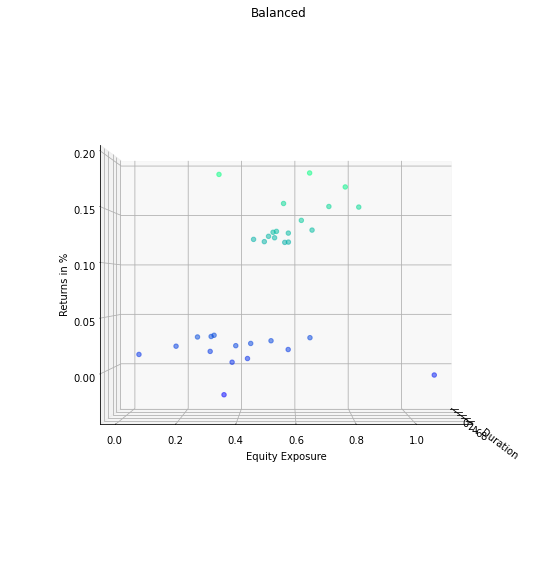

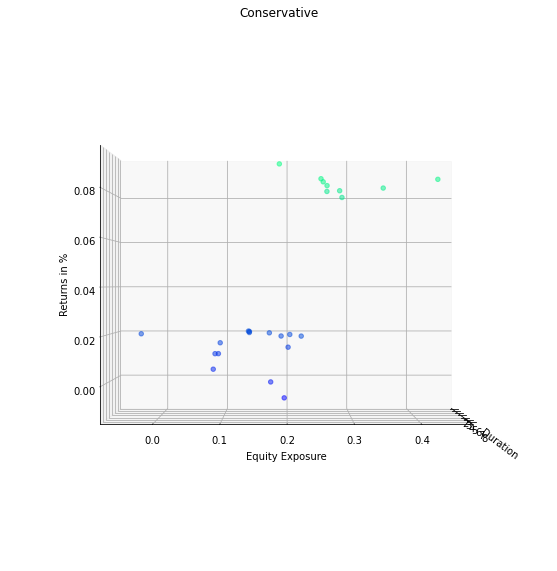

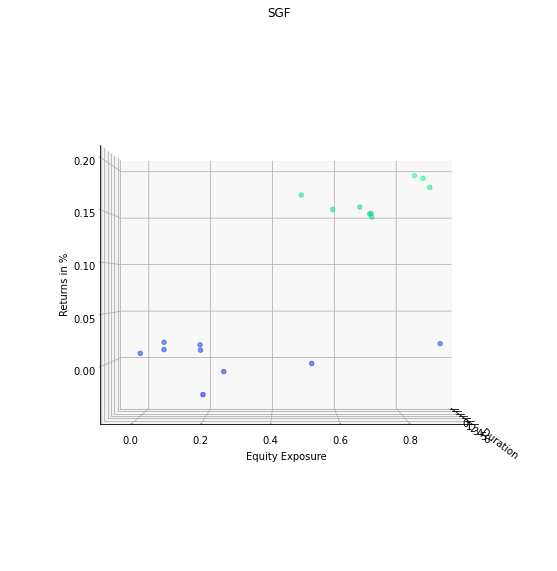

In [17]:
for key in quantiles:
    
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
    
    to_plot=quantiles[key]
    ax.scatter(to_plot['Duration'],to_plot['Equity'],to_plot['Returns'],
               c=to_plot['Returns'],alpha=0.5, cmap='winter')

    elevation_angle = 0
    azimuth_angle = 0
    ax.view_init(elev=elevation_angle, azim=azimuth_angle)
    
    plt.title(label=key,
          fontweight=10,
          pad='2.0')
    
    ax.set_xlabel("Duration",labelpad=10)
    ax.set_ylabel("Equity Exposure",labelpad=10)
    ax.set_zlabel("Returns in %")
    
    plt.show()

## Since August 2024

In [26]:
last_days=90


prices=pd.DataFrame()

for key in reworked_data:
    prices=pd.concat([prices,reworked_data[key]],axis=1)

returns=prices.copy().iloc[-last_days:]
returns=(1+returns.sort_index().fillna(method='bfill').pct_change()).cumprod()-1
returns.iloc[-1].to_excel('Returns.xlsx')

exposure=file.parse(sheet_name=sheet_names[-1])
exposure=exposure.set_index('ISIN')

categories=exposure['Fund'].unique()

maps={}
maps['Balanced']=1
maps['SGF']=2
maps['Conservative']=0
exposure['Fund Name']=names['Fund Name']
exposure['Equity']=exposure['European Equity']+exposure['US equity']
exposure['Returns']=returns.iloc[-1]

exposure['Categories']=exposure['Fund'].map(maps)

# Graphs

## Global Overview

In [27]:
exposure.sort_values(by='Returns',ascending=False).iloc[:10]

,Duration,US equity,European Equity,HY exposure,Fund,Fund Name,Equity,Returns,Categories
ISIN,,,,,,,,,
ES0131445092,NaN,0.868062,0.055371,NaN,SGF,Gestión Boutique VIII Vetusta Inv FI,0.923433,0.084799,2
DE000A2DVS85,6.133788,0.181802,0.232811,NaN,SGF,Opportunistic Deep Value Fund UI I,0.414613,0.066215,2
DE000A0Q8A07,NaN,0.658212,0.091752,NaN,SGF,CONCEPT Aurelia Global,0.749964,0.065911,2
MT7000017331,2.571780,NaN,NaN,NaN,SGF,AQA Flexible Allocation A EUR Acc,NaN,0.065870,2
DE000A1W1PT3,5.566476,0.188945,0.062419,NaN,SGF,W&W Vermögensverwaltende Strategie,0.251364,0.065477,2
ES0182105033,0.986022,0.371043,0.115828,NaN,Balanced,Merch-Universal FI,0.486871,0.062210,1
LU0275643053,0.215242,0.619413,0.200309,NaN,SGF,DWS Funds Invest WachstumsStrategie,0.819722,0.061456,2
ES0174895005,0.761494,0.105723,0.354140,NaN,SGF,Mi Cartera Gestión Dinámica 2 FI,0.459863,0.061324,2
FR0011062686,0.878651,0.244672,0.239643,0.0,SGF,Vital Flex Dynamique,0.484314,0.058215,2


### Balanced Top 10 Peers

In [28]:
exposure[exposure['Fund']==categories[0]].sort_values(by='Returns',ascending=False).iloc[:10]

,Duration,US equity,European Equity,HY exposure,Fund,Fund Name,Equity,Returns,Categories
ISIN,,,,,,,,,
ES0182105033,0.986022,0.371043,0.115828,NaN,Balanced,Merch-Universal FI,0.486871,0.062210,1
AT0000A0H858,1.219984,0.138032,0.182436,NaN,Balanced,Macro + Strategy R T,0.320468,0.057498,1
DE000A1CUGL4,6.828986,0.366621,0.107809,0.000000,Balanced,Global Multi Invest,0.474431,0.055158,1
FR0000981458,4.333561,0.198913,0.228916,0.095046,Balanced,R-co Opal Equilibre,0.427829,0.052244,1
DE000A2PBFM4,4.713210,0.370735,0.347612,0.060037,Balanced,HSBC Horizont 16+ ID,0.718347,0.049061,1
LU0842066523,7.171115,0.249523,0.182308,NaN,Balanced,Sigma Inv. House FCP Balanced A Cl,0.431831,0.047969,1
LU0072229809,5.839749,0.172810,0.280926,0.000000,Balanced,Best-in-One Balanced A EUR,0.453736,0.047563,1
LU0262757841,0.905872,0.417228,0.075148,NaN,Balanced,AZ Fd1 AZ Allc Glbl Bal A-AZ Fd Acc,0.492376,0.047430,1
FR0013183290,3.309535,0.141096,0.189133,0.116851,Balanced,R-co Objectif Croissance,0.330229,0.044580,1


### Conservative Top 10 Peers


In [29]:
exposure[exposure['Fund']==categories[1]].sort_values(by='Returns',ascending=False).iloc[:10]

,Duration,US equity,European Equity,HY exposure,Fund,Fund Name,Equity,Returns,Categories
ISIN,,,,,,,,,
ES0156572002,8.228182,0.063383,0.124907,NaN,Conservative,Myinvestor Cartera Permanente FI,0.188290,0.043618,0
IT0003956197,NaN,0.112670,0.038709,0.153300,Conservative,Arca Strategia Globale Crescita P,0.151378,0.042787,0
LU0330568691,2.640812,NaN,NaN,NaN,Conservative,MPF Renten Strategie Chance,NaN,0.042750,0
LU0327378385,3.671454,0.057148,0.041855,0.184013,Conservative,AlpenPrivatbankVermögensfondsKonservativ,0.099003,0.038925,0
ES0165183007,2.483627,0.046357,0.042506,0.031800,Conservative,Mutuafondo Mixto Selección A FI,0.088863,0.038056,0
ES0173840002,3.501426,0.000162,0.000784,0.267000,Conservative,Sássola Selección Base A FI,0.000945,0.037717,0
LU0349157924,5.045295,0.052740,0.092875,NaN,Conservative,Fonditalia Core 1 R,0.145615,0.037590,0
DK0060816221,NaN,0.151327,0.079071,NaN,Conservative,Nykredit Invest Bal Defensiv - Ptfpl KL,0.230398,0.037094,0
LU1090960755,3.310509,0.127111,0.102342,NaN,Conservative,Eurizon Conservative Allc R EUR Acc,0.229453,0.036970,0


### Dynamic Top 10 Peers


In [30]:
exposure[exposure['Fund']==categories[2]].sort_values(by='Returns',ascending=False).iloc[:10]

,Duration,US equity,European Equity,HY exposure,Fund,Fund Name,Equity,Returns,Categories
ISIN,,,,,,,,,
ES0131445092,NaN,0.868062,0.055371,NaN,SGF,Gestión Boutique VIII Vetusta Inv FI,0.923433,0.084799,2
DE000A2DVS85,6.133788,0.181802,0.232811,NaN,SGF,Opportunistic Deep Value Fund UI I,0.414613,0.066215,2
DE000A0Q8A07,NaN,0.658212,0.091752,NaN,SGF,CONCEPT Aurelia Global,0.749964,0.065911,2
MT7000017331,2.571780,NaN,NaN,NaN,SGF,AQA Flexible Allocation A EUR Acc,NaN,0.065870,2
DE000A1W1PT3,5.566476,0.188945,0.062419,NaN,SGF,W&W Vermögensverwaltende Strategie,0.251364,0.065477,2
LU0275643053,0.215242,0.619413,0.200309,NaN,SGF,DWS Funds Invest WachstumsStrategie,0.819722,0.061456,2
ES0174895005,0.761494,0.105723,0.354140,NaN,SGF,Mi Cartera Gestión Dinámica 2 FI,0.459863,0.061324,2
FR0011062686,0.878651,0.244672,0.239643,0.000000,SGF,Vital Flex Dynamique,0.484314,0.058215,2
FI4000210539,3.684189,0.353036,0.184763,NaN,SGF,OP-Kestävä Maailma A,0.537799,0.057952,2


### Regression

In [ ]:
inputs=exposure.copy()
#inputs=inputs.interpolate()
inputs=inputs.dropna()

X=normalize(inputs[['Equity','Duration']])
Y=normalize(inputs['Returns'])

Reg=LinearRegression(X,Y)

weights,bias=Reg.fit()

x1_grid, x2_grid = np.meshgrid(np.linspace(-4,4, 1000),np.linspace(-4,4, 1000))
z=weights[0]*x1_grid+weights[1]*x2_grid+bias

equity=denormalize(x1_grid,inputs['Equity'])
duration=denormalize(x2_grid,inputs['Duration'])
score=denormalize(z,inputs['Returns'])

In [ ]:
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(duration,equity,score,alpha=0.1
               )

ax.scatter(exposure['Duration'],exposure['Equity'],exposure['Returns'],
           c=exposure['Categories'],alpha=0.5
           , cmap='winter',zorder=0)


plt.title(label='Funds',
      fontweight=10,
      pad='2.0')

ax.set_xlabel("Duration",labelpad=10)
ax.set_ylabel("Equity Exposure",labelpad=10)
ax.set_zlabel("Returns in %")

elevation_angle = 0
azimuth_angle = 0
ax.view_init(elev=elevation_angle, azim=azimuth_angle)
plt.show()

## View by type and quantile

In [ ]:
for variable in categories:
 
    inputs=exposure[exposure['Fund']==variable]
    inputs=inputs.dropna()


    X=normalize(inputs[['Equity','Duration']])
    Y=normalize(inputs['Returns'])
    Reg=LinearRegression(X,Y)
    weights,bias=Reg.fit()
    
    x1_grid, x2_grid = np.meshgrid(np.linspace(-6,6, 1000),np.linspace(-6,6, 1000))
    z=weights[0]*x1_grid+weights[1]*x2_grid+bias
    
    equity=denormalize(x1_grid,inputs['Equity'])
    duration=denormalize(x2_grid,inputs['Duration'])
    score=denormalize(z,inputs['Returns'])

    
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')
     
    ax.plot_surface(duration,equity,score,alpha=0.1
               )
    
    
    ax.scatter(exposure[exposure['Fund']==variable]['Duration'],exposure[exposure['Fund']==variable]['Equity'],exposure[exposure['Fund']==variable]['Returns'],
               c=exposure[exposure['Fund']==variable]['Returns'],alpha=0.7, cmap='winter')
    
    plt.title(label=variable,
          fontweight=10,
          pad='2.0')
    
    ax.set_xlabel("Duration",labelpad=10)
    ax.set_ylabel("Equity Exposure",labelpad=10)
    ax.set_zlabel("Returns in %")
    
    elevation_angle = 10
    azimuth_angle = 25
    ax.view_init(elev=elevation_angle, azim=azimuth_angle)
    plt.show()